<a href="https://colab.research.google.com/github/krrish9973/C-/blob/master/Project_CV_Scene_Understanding_Navigation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scene Understanding for Indoor/Outdoor Navigation Assistance

This notebook implements an integrated scene understanding system with:
- Object Detection (YOLOv8)
- Semantic Segmentation (DeepLabV3)
- Depth Estimation (MiDaS)

It will be used later as the practical basis for the project report.

#Colab Environment Information Code

In [20]:
import torch
import platform
import subprocess
import sys
import os

print("===== GOOGLE COLAB ENVIRONMENT INFORMATION =====\n")

# Python version
print(f"Python Version      : {sys.version}\n")

# OS & Kernel
print(f"Operating System    : {platform.system()} {platform.release()}")
print(f"Kernel Version      : {platform.version()}\n")

# CPU info
print("===== CPU INFO =====")
cpu_info = !lscpu
print("\n".join(cpu_info), "\n")

# RAM info
print("===== RAM INFO =====")
ram_info = !free -h
print("\n".join(ram_info), "\n")

# GPU info
print("===== GPU INFO =====")
gpu_info = !nvidia-smi
print("\n".join(gpu_info), "\n")

# CUDA info
if torch.cuda.is_available():
    print("CUDA Available      : Yes")
    print("CUDA Version        :", torch.version.cuda)
    print("cuDNN Version       :", torch.backends.cudnn.version())
    print("GPU Name            :", torch.cuda.get_device_name(0))
else:
    print("CUDA Available      : No")

print("\n===== PYTORCH INFO =====")
print("PyTorch Version     :", torch.__version__)
print("Is CUDA Enabled?    :", torch.cuda.is_available())
print("PyTorch Build Info  :\n", torch.__config__.show())


===== GOOGLE COLAB ENVIRONMENT INFORMATION =====

Python Version      : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]

Operating System    : Linux 6.6.105+
Kernel Version      : #1 SMP Thu Oct  2 10:42:05 UTC 2025

===== CPU INFO =====
Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      12
  On-line CPU(s) list:       0-11
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      6
    Socket(s):               1
    Stepping:                7
    BogoMIPS:                4400.32
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                   

#Step 1 – Install Dependencies

In [1]:
!pip install ultralytics --quiet
!pip install opencv-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.4 MB/s eta 0:00:00


In [2]:
# !pip install ultralytics==8.3.0 --quiet
# !pip install opencv-python --quiet

import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.9.0+cu126
CUDA available: True


#Step 2 – Imports and Device Selection

In [3]:
import os
import cv2
import time
import glob
import numpy as np
from typing import Dict, Any

import torch
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision

from ultralytics import YOLO
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda


# Step 3 – Object Detection: YOLOv8 Wrapper

In [4]:
class ObjectDetector:
    def __init__(self, model_path: str = "yolov8n.pt", device: str = "cpu"):
        """
        Wrapper for YOLOv8 object detection.
        model_path: can be "yolov8n.pt", "yolov8s.pt", etc.
        """
        self.device = device
        self.model = YOLO(model_path)

    def predict(self, image_bgr: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Runs YOLOv8 on a BGR image (OpenCV format).
        Returns dict with:
            boxes: [N, 4] (x1,y1,x2,y2)
            scores: [N]
            class_ids: [N]
        """
        results = self.model.predict(
            source=image_bgr,
            device=self.device,
            verbose=False
        )[0]

        if results.boxes is None or len(results.boxes) == 0:
            return {
                "boxes": np.zeros((0, 4)),
                "scores": np.zeros((0,)),
                "class_ids": np.zeros((0,), dtype=int),
            }

        boxes = results.boxes.xyxy.cpu().numpy()
        scores = results.boxes.conf.cpu().numpy()
        class_ids = results.boxes.cls.cpu().numpy().astype(int)

        return {
            "boxes": boxes,
            "scores": scores,
            "class_ids": class_ids,
        }

# Step 4 – Semantic Segmentation: DeepLabV3 (Torchvision)

In [5]:
from PIL import Image

class SemanticSegmenter:
    def __init__(self, device: str = "cpu"):
        """
        DeepLabV3-ResNet101 pretrained on COCO.
        """
        self.device = device

        self.model = torchvision.models.segmentation.deeplabv3_resnet101(
            weights=torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
        ).to(self.device)
        self.model.eval()

        weights = torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
        self.preprocess = weights.transforms()  # expects PIL Image or Tensor

    def predict(self, image_bgr: np.ndarray) -> np.ndarray:
        """
        Returns a HxW numpy array of class indices.
        """
        # Convert BGR (OpenCV) -> RGB
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        # Convert NumPy array -> PIL Image for torchvision transforms
        image_pil = Image.fromarray(image_rgb)

        # Apply pretrained transforms and move to device
        inp = self.preprocess(image_pil).unsqueeze(0).to(self.device)

        with torch.no_grad():
            out = self.model(inp)["out"]  # [1, C, H, W]
            seg = out.argmax(1).squeeze(0).cpu().numpy()

        return seg

# Step 5 – Depth Estimation: MiDaS / DPT

In [6]:
class DepthEstimator:
    def __init__(self, device: str = "cpu", model_type: str = "DPT_Large"):
        """
        model_type: "DPT_Large", "DPT_Hybrid", or "MiDaS_small"
        Uses torch.hub to load Intel's MiDaS models.
        """
        self.device = device
        self.model_type = model_type

        # Load MiDaS model & transforms
        self.model = torch.hub.load("intel-isl/MiDaS", model_type).to(self.device)
        self.model.eval()
        transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

        if model_type in ["DPT_Large", "DPT_Hybrid"]:
            self.tf = transforms.dpt_transform
        else:
            self.tf = transforms.small_transform

    def predict(self, image_bgr: np.ndarray) -> np.ndarray:
        """
        Returns a HxW depth map normalized to [0,1].
        """
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        inp = self.tf(image_rgb).to(self.device)

        with torch.no_grad():
            prediction = self.model(inp)
            prediction = F.interpolate(
                prediction.unsqueeze(1),
                size=image_rgb.shape[:2],
                mode="bicubic",
                align_corners=False,
            ).squeeze()
        depth = prediction.cpu().numpy()

        depth_norm = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)
        return depth_norm

# Step 6 – Integrated Scene Understanding System

In [14]:
class SceneUnderstandingSystem:
    def __init__(self,
                 det_model_path: str = "yolov8n.pt",
                 depth_model_type: str = "DPT_Large",
                 device: str = "cpu"):
        self.device = device
        print(f"Initializing system on device: {self.device}")

        self.detector = ObjectDetector(det_model_path, device=self.device)
        self.segmenter = SemanticSegmenter(device=self.device)
        self.depth_estimator = DepthEstimator(device=self.device,
                                              model_type=depth_model_type)

        self.seg_color_map = self._create_color_map(256)

    @staticmethod
    def _create_color_map(num_classes: int):
        """
        Creates a deterministic color map for segmentation visualization.
        """
        np.random.seed(0)
        return np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)

    def process_frame(self, frame_bgr: np.ndarray) -> Dict[str, Any]:
        """
        Process one frame: detection, segmentation, depth, and fused visualization.
        """
        det = self.detector.predict(frame_bgr)
        seg_mask = self.segmenter.predict(frame_bgr)
        depth_map = self.depth_estimator.predict(frame_bgr)

        vis = self._create_fused_visualization(frame_bgr, det, seg_mask, depth_map)

        return {
            "detections": det,
            "segmentation": seg_mask,
            "depth": depth_map,
            "vis": vis,
        }

    def _create_fused_visualization(self,
                                frame_bgr: np.ndarray,
                                det: Dict[str, np.ndarray],
                                seg_mask: np.ndarray,
                                depth_map: np.ndarray) -> np.ndarray:
      """
      Overlays segmentation & depth (as heatmap), draws detection boxes,
      and adds a legend explaining each component.
      """
      h, w = frame_bgr.shape[:2]

      # 1) Resize seg_mask to match original frame size
      if seg_mask.shape != (h, w):
          seg_mask_resized = cv2.resize(
              seg_mask.astype(np.uint8),
              (w, h),
              interpolation=cv2.INTER_NEAREST
          )
      else:
          seg_mask_resized = seg_mask.astype(np.uint8)

      # 2) Segmentation overlay
      seg_idx = seg_mask_resized.astype(np.int32)
      seg_idx = np.clip(seg_idx, 0, self.seg_color_map.shape[0] - 1)

      seg_color = self.seg_color_map[seg_idx]
      seg_overlay = cv2.addWeighted(frame_bgr, 0.5, seg_color, 0.5, 0)

      # 3) Depth heatmap
      depth_uint8 = (depth_map * 255).astype(np.uint8)
      depth_color = cv2.applyColorMap(depth_uint8, cv2.COLORMAP_PLASMA)
      depth_overlay = cv2.addWeighted(seg_overlay, 0.7, depth_color, 0.3, 0)

      # 4) Draw YOLO detections (object detection boxes)
      boxes = det["boxes"]
      scores = det["scores"]
      class_ids = det["class_ids"]

      for box, score, cid in zip(boxes, scores, class_ids):
          x1, y1, x2, y2 = box.astype(int)
          cv2.rectangle(depth_overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)
          label = f"{cid}:{score:.2f}"
          cv2.putText(
              depth_overlay,
              label,
              (x1, max(0, y1 - 5)),
              cv2.FONT_HERSHEY_SIMPLEX,
              0.5,
              (0, 255, 0),
              1,
              cv2.LINE_AA,
          )

      # 5) Add legend box explaining the three components
      legend_x, legend_y = 10, 30
      legend_w, legend_h = 360, 90

      # Draw filled black rectangle as background for legend
      cv2.rectangle(
          depth_overlay,
          (legend_x, legend_y - 20),
          (legend_x + legend_w, legend_y - 20 + legend_h),
          (0, 0, 0),
          thickness=-1,
      )

      # Legend text lines
      cv2.putText(
          depth_overlay,
          "Object detection: green boxes",
          (legend_x + 10, legend_y),
          cv2.FONT_HERSHEY_SIMPLEX,
          0.6,
          (0, 255, 0),
          1,
          cv2.LINE_AA,
      )

      cv2.putText(
          depth_overlay,
          "Semantic segmentation: colored regions",
          (legend_x + 10, legend_y + 30),
          cv2.FONT_HERSHEY_SIMPLEX,
          0.6,
          (255, 255, 255),
          1,
          cv2.LINE_AA,
      )

      cv2.putText(
          depth_overlay,
          "Depth estimation: color gradient overlay",
          (legend_x + 10, legend_y + 60),
          cv2.FONT_HERSHEY_SIMPLEX,
          0.6,
          (255, 255, 255),
          1,
          cv2.LINE_AA,
      )

      return depth_overlay


# Step 7 – Single-Image Demo (Upload Image in Colab)

In [15]:
from google.colab import files

print("Upload one or more images (jpg/png).")
uploaded = files.upload()

os.makedirs("data/images", exist_ok=True)
for fname in uploaded.keys():
    src = fname
    dst = os.path.join("data/images", fname)
    os.rename(src, dst)
    print("Saved to:", dst)


Upload one or more images (jpg/png).


Saving bus.jpg to bus.jpg
Saved to: data/images/bus.jpg


Initializing system on device: cuda


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Images: ['data/images/bus.jpg']


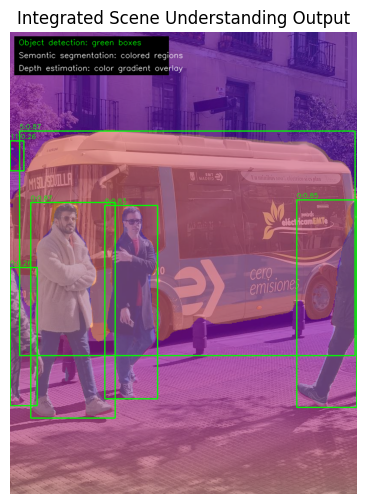

In [16]:
system = SceneUnderstandingSystem(
    det_model_path="yolov8n.pt",
    depth_model_type="DPT_Large",
    device=device
)

# Pick first uploaded image
image_paths = sorted(glob.glob("data/images/*"))
print("Images:", image_paths)

if len(image_paths) > 0:
    img_path = image_paths[0]
    frame_bgr = cv2.imread(img_path)
    result = system.process_frame(frame_bgr)

    vis = result["vis"]
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(vis_rgb)
    plt.axis("off")
    plt.title("Integrated Scene Understanding Output")
    plt.show()
else:
    print("No images found in data/images")


# Step 8 – Run on Folder of Images & Save Outputs

In [17]:
def run_on_image_folder(system: SceneUnderstandingSystem,
                        input_dir: str,
                        output_dir: str):
    os.makedirs(output_dir, exist_ok=True)
    image_paths = sorted(
        glob.glob(os.path.join(input_dir, "*.jpg"))
        + glob.glob(os.path.join(input_dir, "*.png"))
        + glob.glob(os.path.join(input_dir, "*.jpeg"))
    )

    print(f"Found {len(image_paths)} images in {input_dir}")

    for img_path in image_paths:
        frame_bgr = cv2.imread(img_path)
        if frame_bgr is None:
            print(f"Could not read image: {img_path}")
            continue

        start = time.time()
        result = system.process_frame(frame_bgr)
        elapsed = time.time() - start

        vis = result["vis"]
        fname = os.path.basename(img_path)
        out_path = os.path.join(output_dir, fname)

        cv2.putText(
            vis,
            f"{elapsed:.3f} s/frame",
            (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

        cv2.imwrite(out_path, vis)
        print(f"Saved: {out_path} (time: {elapsed:.3f}s)")

# Run batch processing
run_on_image_folder(
    system,
    input_dir="data/images",
    output_dir="outputs/visualizations"
)


Found 1 images in data/images
Saved: outputs/visualizations/bus.jpg (time: 0.144s)


#🎬 Step 9 – Video Demo (for YouTube / OneDrive)

In [19]:
def run_on_video(system: SceneUnderstandingSystem,
                 video_path: str,
                 output_path: str,
                 max_frames: int = None):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Could not open video: {video_path}")
        return

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_idx = 0
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_idx += 1
        if max_frames is not None and frame_idx > max_frames:
            break

        start = time.time()
        result = system.process_frame(frame_bgr)
        elapsed = time.time() - start

        vis = result["vis"]
        cv2.putText(
            vis,
            f"Frame {frame_idx} | {elapsed:.3f} s",
            (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

        writer.write(vis)
        print(f"Processed frame {frame_idx}, time: {elapsed:.3f}s")

    cap.release()
    writer.release()
    print(f"Saved output video to: {output_path}")

# Example usage:
input_video = "home_.mp4"  # change to your uploaded file
output_video = "outputs/video/scene_understanding_demo.mp4"

run_on_video(system, input_video, output_video, max_frames=200)


Processed frame 1, time: 0.155s
Processed frame 2, time: 0.131s
Processed frame 3, time: 0.131s
Processed frame 4, time: 0.130s
Processed frame 5, time: 0.131s
Processed frame 6, time: 0.131s
Processed frame 7, time: 0.130s
Processed frame 8, time: 0.129s
Processed frame 9, time: 0.129s
Processed frame 10, time: 0.130s
Processed frame 11, time: 0.129s
Processed frame 12, time: 0.129s
Processed frame 13, time: 0.129s
Processed frame 14, time: 0.131s
Processed frame 15, time: 0.129s
Processed frame 16, time: 0.129s
Processed frame 17, time: 0.129s
Processed frame 18, time: 0.129s
Processed frame 19, time: 0.129s
Processed frame 20, time: 0.129s
Processed frame 21, time: 0.131s
Processed frame 22, time: 0.130s
Processed frame 23, time: 0.129s
Processed frame 24, time: 0.129s
Processed frame 25, time: 0.129s
Processed frame 26, time: 0.130s
Processed frame 27, time: 0.129s
Processed frame 28, time: 0.129s
Processed frame 29, time: 0.131s
Processed frame 30, time: 0.130s
Processed frame 31,